In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
gunavenkatdoddi_eye_diseases_classification_path = kagglehub.dataset_download('gunavenkatdoddi/eye-diseases-classification')

print('Data source import complete.')


Using Colab cache for faster access to the 'eye-diseases-classification' dataset.
Data source import complete.


In [2]:
# ===========================
# Standard Libraries
# ===========================
import os
import random
import warnings

# ===========================
# Numerical & Data Processing
# ===========================
import numpy as np
import pandas as pd

# ===========================
# Image Processing
# ===========================
import cv2
from PIL import Image

# ===========================
# Visualization
# ===========================
import matplotlib.pyplot as plt
import seaborn as sns

# ===========================
# PyTorch
# ===========================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms, models
from torch.utils.tensorboard import SummaryWriter

# ===========================
# Evaluation
# ===========================
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

warnings.filterwarnings("ignore")

In [3]:
def visualize_images(path, target_size=(256, 256), num_images=5):
    """
    Display random images from a directory.

    Args:
        path (str): Directory containing images.
        target_size (tuple): Desired image size (width, height).
        num_images (int): Number of images to display.
    """

    # Get all image files
    image_filenames = [
        f for f in os.listdir(path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'))
    ]

    if len(image_filenames) == 0:
        raise ValueError("No images found in the specified directory.")

    # Select random images
    selected_images = random.sample(
        image_filenames,
        min(num_images, len(image_filenames))
    )

    # Plot images
    fig, axes = plt.subplots(
        1,
        len(selected_images),
        figsize=(3 * len(selected_images), 3)
    )

    # Handle the case when only one image is displayed
    if len(selected_images) == 1:
        axes = [axes]

    for ax, image_name in zip(axes, selected_images):
        image_path = os.path.join(path, image_name)

        image = Image.open(image_path).convert("RGB")
        image = image.resize(target_size)

        ax.imshow(image)
        ax.set_title(image_name, fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Downloading/Loading dataset via kagglehub...
Using Colab cache for faster access to the 'eye-diseases-classification' dataset.
Dataset location: /kaggle/input/eye-diseases-classification
Detected Classes: ['Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Normal']

Count matrix (rows = Train, Validation, Test):
[[726 768 705 752]
 [156 165 151 161]
 [156 165 151 161]]

Plot saved as 'dataset_distribution.png'


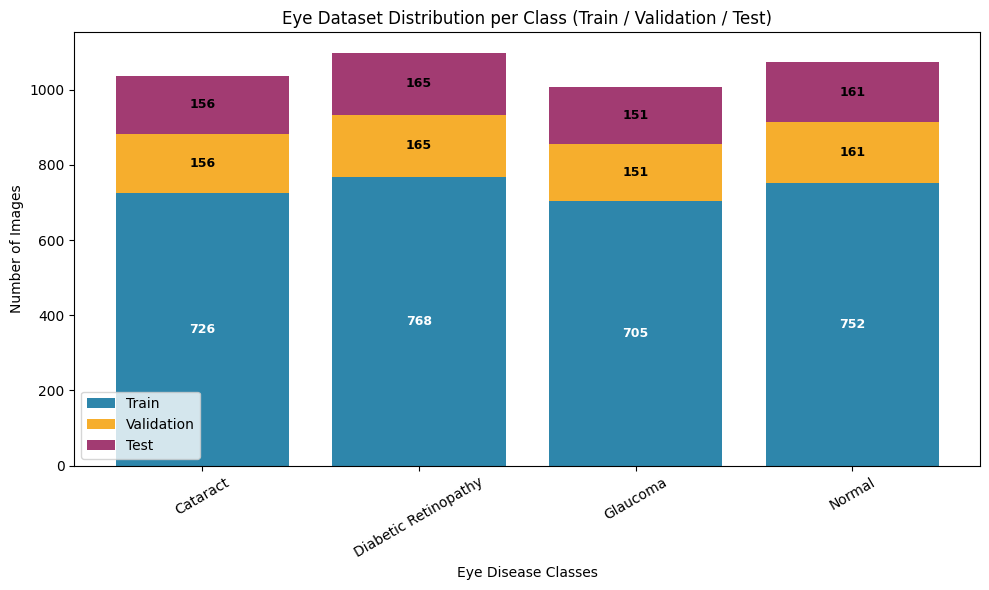

In [4]:
# ==============================================================================
# DATASET DISTRIBUTION VISUALIZATION (KaggleHub Integration)
# ==============================================================================
# METHODOLOGY JUSTIFICATION FOR PAPER (Handling Class Imbalance)
# ==============================================================================
# 1. Stratified Splitting: The dataset is split using stratification to ensure
#    the original class distribution is strictly preserved across Train,
#    Validation, and Test sets. This prevents evaluation bias.
# 2. Dynamic Fetching: The dataset is fetched dynamically using kagglehub,
#    ensuring reproducibility without relying on static local CSV files.
# 3. Class Weighting & Augmentation: Addressed in the main pipeline to handle
#    any identified imbalances shown in this plot.
# ==============================================================================

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------------------------
# 1. Download and parse the dataset dynamically
# ------------------------------------------------------------------------------

print("Downloading/Loading dataset via kagglehub...")

path = kagglehub.dataset_download('gunavenkatdoddi/eye-diseases-classification')
print(f"Dataset location: {path}")

data_root = os.path.join(path, 'dataset')
if not os.path.exists(data_root):
    data_root = path

# Detect original class names (used internally)
classes = sorted([
    d for d in os.listdir(data_root)
    if os.path.isdir(os.path.join(data_root, d))
])

# Display names (used for plotting and printing)
display_classes = [cls.replace('_', ' ').title() for cls in classes]

print(f"Detected Classes: {display_classes}")

all_image_paths = []
all_labels = []

for idx, cls_name in enumerate(classes):
    cls_folder = os.path.join(data_root, cls_name)

    images = glob.glob(os.path.join(cls_folder, "*"))
    images = [
        img for img in images
        if img.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    for img_path in images:
        all_image_paths.append(img_path)
        all_labels.append(idx)

# ------------------------------------------------------------------------------
# 2. Perform the exact same Stratified Split as the main pipeline
# ------------------------------------------------------------------------------

SEED = 42

X_train, X_temp, y_train, y_temp = train_test_split(
    all_image_paths,
    all_labels,
    test_size=0.30,
    stratify=all_labels,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

splits = ['Train', 'Validation', 'Test']
split_labels = [y_train, y_val, y_test]

# ------------------------------------------------------------------------------
# 3. Calculate counts for each split
# ------------------------------------------------------------------------------

counts = []

for split_label_list in split_labels:
    split_counts = [split_label_list.count(i) for i in range(len(classes))]
    counts.append(split_counts)

counts = np.array(counts)

print("\nCount matrix (rows = Train, Validation, Test):")
print(counts)

# ------------------------------------------------------------------------------
# 4. Plot stacked bar chart
# ------------------------------------------------------------------------------

x = np.arange(len(classes))

fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(classes))

colors = [
    '#2E86AB',  # Train
    '#F6AE2D',  # Validation
    '#A23B72'   # Test
]

for i, split in enumerate(splits):
    ax.bar(
        x,
        counts[i],
        bottom=bottom,
        label=split,
        color=colors[i]
    )
    bottom += counts[i]

# Display class names nicely
ax.set_xticks(x)
ax.set_xticklabels(display_classes, rotation=30)

ax.set_ylabel("Number of Images")
ax.set_xlabel("Eye Disease Classes")
ax.set_title("Eye Dataset Distribution per Class (Train / Validation / Test)")

ax.legend()

# ------------------------------------------------------------------------------
# Add numeric labels inside each bar
# ------------------------------------------------------------------------------

bottom = np.zeros(len(classes))

for i in range(len(splits)):
    for j in range(len(classes)):

        height = counts[i][j]

        if height > 0:
            ax.text(
                j,
                bottom[j] + height / 2,
                str(height),
                ha='center',
                va='center',
                fontsize=9,
                fontweight='bold',
                color='white' if i == 0 else 'black'
            )

    bottom += counts[i]

plt.tight_layout()

plt.savefig(
    "dataset_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

print("\nPlot saved as 'dataset_distribution.png'")

plt.show()

Re-obtaining dataset path for visualization...
Using Colab cache for faster access to the 'eye-diseases-classification' dataset.
Detected Classes: ['Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Normal']

Saved plot as: dataset_samples.png


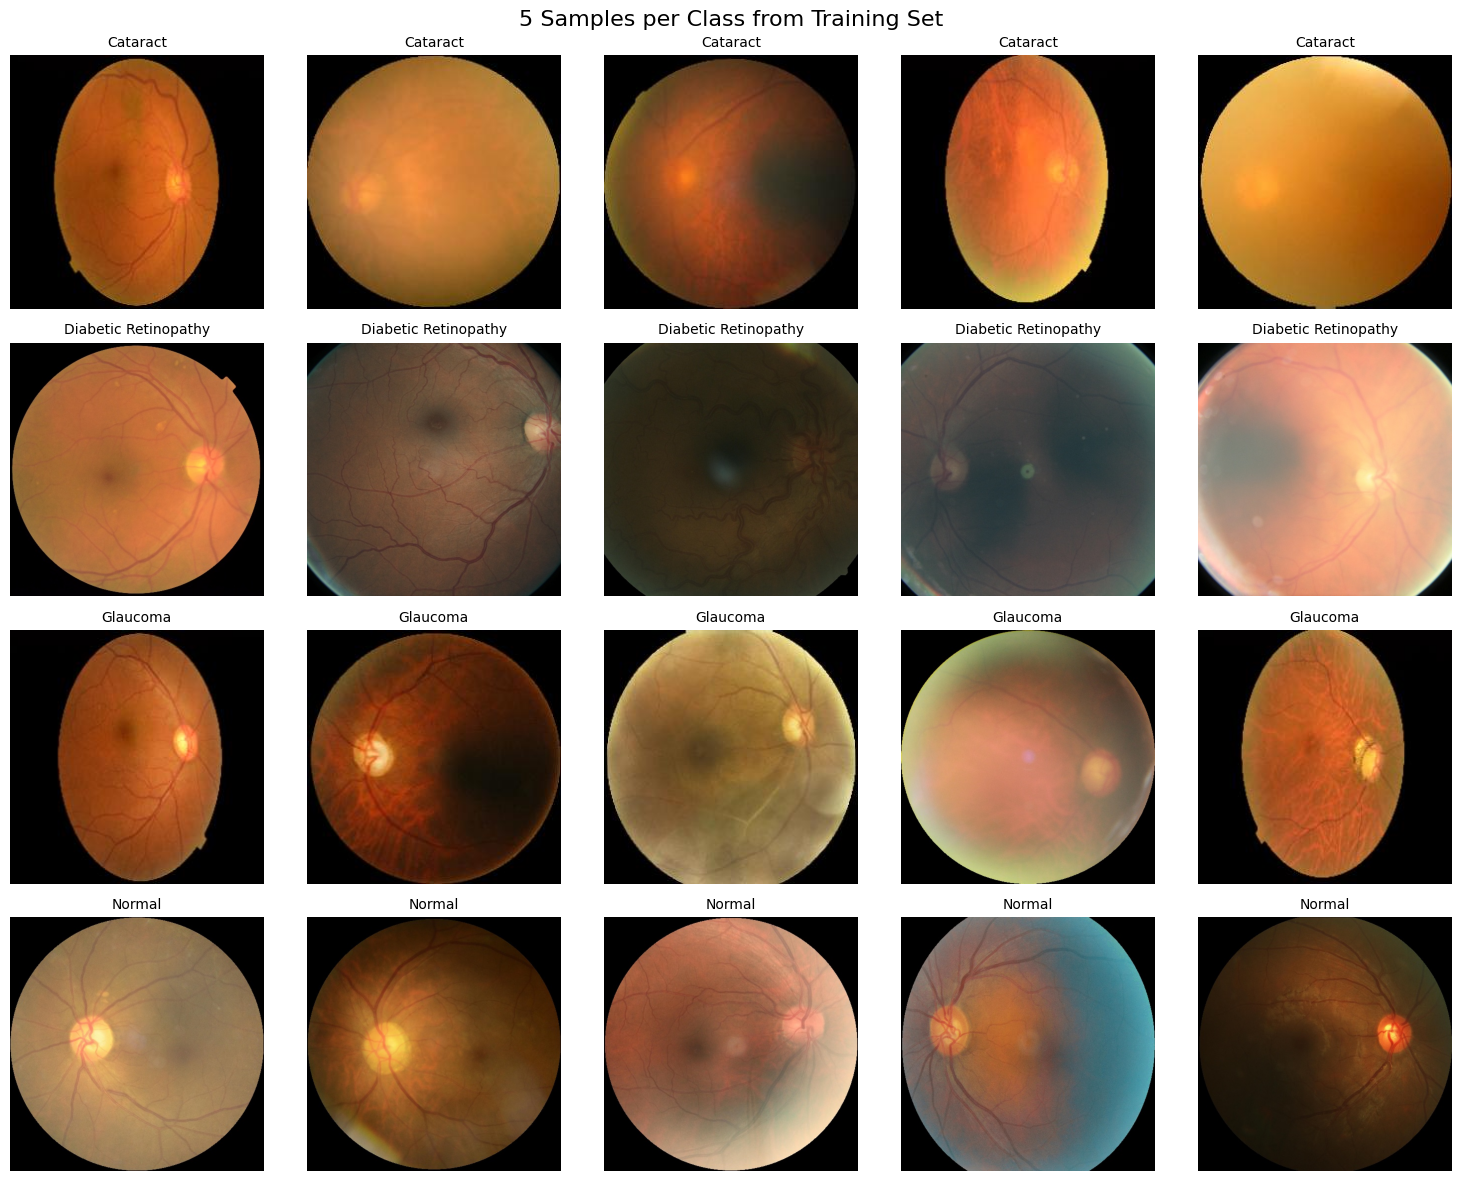

In [5]:
# ==============================================================================
# DATASET SAMPLES VISUALIZATION (From Training Split)
# ==============================================================================
# This script visualizes random samples per class from the training split,
# reconstructing the split directly from the dataset source.
# It ensures we are viewing raw images BEFORE augmentation.
# ==============================================================================

import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import kagglehub
import glob
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------------------------
# Function
# ------------------------------------------------------------------------------

def plot_random_samples_from_source(n_samples=5):

    SEED = 42

    print("Re-obtaining dataset path for visualization...")

    # Download dataset
    path = kagglehub.dataset_download(
        'gunavenkatdoddi/eye-diseases-classification'
    )

    data_root = os.path.join(path, 'dataset')
    if not os.path.exists(data_root):
        data_root = path

    # ------------------------------------------------------------------------------
    # Detect classes automatically from folder structure
    # ------------------------------------------------------------------------------

    classes = sorted([
        d for d in os.listdir(data_root)
        if os.path.isdir(os.path.join(data_root, d))
    ])

    # Pretty names for visualization
    display_classes = [cls.replace('_', ' ').title() for cls in classes]

    print(f"Detected Classes: {display_classes}")

    # ------------------------------------------------------------------------------
    # Load dataset paths and labels
    # ------------------------------------------------------------------------------

    all_image_paths = []
    all_labels = []

    for idx, cls_name in enumerate(classes):

        cls_folder = os.path.join(data_root, cls_name)

        images = glob.glob(os.path.join(cls_folder, "*"))
        images = [
            img for img in images
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]

        for img_path in images:
            all_image_paths.append(img_path)
            all_labels.append(idx)

    # ------------------------------------------------------------------------------
    # Train split (same as pipeline)
    # ------------------------------------------------------------------------------

    X_train, X_temp, y_train, y_temp = train_test_split(
        all_image_paths,
        all_labels,
        test_size=0.30,
        stratify=all_labels,
        random_state=SEED
    )

    train_data = list(zip(X_train, y_train))

    # ------------------------------------------------------------------------------
    # Plot setup
    # ------------------------------------------------------------------------------

    fig, axes = plt.subplots(
        len(classes),
        n_samples,
        figsize=(15, 12)
    )

    # Fix for single-class edge case
    if len(classes) == 1:
        axes = [axes]

    # ------------------------------------------------------------------------------
    # Plot samples per class
    # ------------------------------------------------------------------------------

    for i, cls_name in enumerate(classes):

        class_samples = [
            item for item in train_data
            if item[1] == i
        ]

        image_paths = [item[0] for item in class_samples]

        random.seed(SEED)

        samples = random.sample(
            image_paths,
            min(n_samples, len(image_paths))
        )

        for j in range(n_samples):

            ax = axes[i, j]

            if j < len(samples):
                try:
                    img = Image.open(samples[j]).convert("RGB")
                    ax.imshow(img)
                except Exception as e:
                    print(f"Error loading {samples[j]}: {e}")

            ax.axis("off")

            # Show clean class name
            ax.set_title(
                display_classes[i],
                fontsize=10,
                fontweight='medium'
            )

    # ------------------------------------------------------------------------------
    # Final layout
    # ------------------------------------------------------------------------------

    plt.suptitle(
        f"{n_samples} Samples per Class from Training Set",
        fontsize=16,
        y=0.98
    )

    plt.tight_layout()

    save_path = "dataset_samples.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    print(f"\nSaved plot as: {save_path}")

    plt.show()


# ------------------------------------------------------------------------------
# Run
# ------------------------------------------------------------------------------

if __name__ == "__main__":
    plot_random_samples_from_source()

<a id="1"></a>
<div id="animated-container" style="position: relative;
            border-radius: 10px;
            padding: 10px;
            font-family: Arial, sans-serif;
            font-size: 36px;
            font-weight: 900;
            color: black;
            display: inline-block;
            text-transform: uppercase;
            box-shadow: 2px 2px 4px #888;
            text-shadow: 2px 2px 4px #888;
            overflow: hidden;
            background-color: #800606 ;
            cursor: pointer;" onclick="toggleAnimation()"> <!-- Added cursor pointer and onclick event -->
    <div style="position: absolute;
                top: 50%;
                right: 0; /* Adjusted to place on the right side */
                transform: translateY(45%);">
        <!-- <img src="https://www.kaggle.com/static/images/tier-animation-transparent.gif" alt="Cartoon Character" style="height: 100px; width: auto;"> -->
    </div>
    <div style="font-weight: bold;"></div>
    <span style="font-style: italic; text-shadow: 2px 2px 4px #888; color: white;">Cataract 👁️‍🗨️</span>
         <!-- <img src="https://pin.it/6mmgqwOvV" alt="Cartoon Character" style="height: 50px; width: auto;"> -->
</div>

<script>
    function toggleAnimation() {
        var container = document.getElementById('animated-container');
        var animationDiv = container.querySelector('div');
        if (animationDiv.style.animationPlayState === 'paused') {
            animationDiv.style.animationPlayState = 'running';
        } else {
            animationDiv.style.animationPlayState = 'paused';
        }
    }
</script>


In [6]:
pip install thop

In [7]:
# =========================================================================
# 5-FOLD CROSS VALIDATION PIPELINE (CLEANED FOR NEW DATASET)
# =========================================================================

import os, random, time, gc, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, cohen_kappa_score,
                             matthews_corrcoef, log_loss, roc_auc_score,
                             brier_score_loss)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
from scipy.optimize import minimize
from scipy.stats import wilcoxon
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
from tqdm import tqdm
from PIL import Image
import kagglehub
import warnings

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# ------------------------------------------------------------------
# 1. Configuration and globals
# ------------------------------------------------------------------
SEED = 42
EPOCHS = 30
PATIENCE = 3
BATCH = 64
LR = 5e-4
WARMUP_EPOCHS = 3
MIXUP_ALPHA = 0.2
IMG_SIZE = 224

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0

CLASSES = []
N_CLASSES = 0
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
LABEL_SMOOTHING = 0.1

SAVE_DIR = './results_new_dataset'
LATEX_DIR = os.path.join(SAVE_DIR, 'latex_tables')
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(LATEX_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ------------------------------------------------------------------
# 2. Data Preparation & Transforms
# ------------------------------------------------------------------
def prepare_data():
    global CLASSES, N_CLASSES
    print("Downloading/Loading dataset via kagglehub...")

    # ⚠️ توجـــه: لینک دیتاست جدید خود را در خط زیر جایگزین کنید
    path = kagglehub.dataset_download('gunavenkatdoddi/eye-diseases-classification')

    data_root = os.path.join(path, 'dataset')
    if not os.path.exists(data_root):
        data_root = path

    raw_classes = sorted([d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d))])

    # ⚠️ توجـــه: نام کلاس‌های دیتاست جدید خود را در اینجا وارد کنید
    CLASSES = ['Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Normal']
    N_CLASSES = len(CLASSES)

    all_image_paths, all_labels = [], []
    for idx, cls_name_raw in enumerate(raw_classes):
        cls_folder = os.path.join(data_root, cls_name_raw)
        images = glob.glob(os.path.join(cls_folder, "*"))
        images = [img for img in images if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for img_path in images:
            all_image_paths.append(img_path)
            all_labels.append(idx)

    # For K-Fold, we can just use train+val pool
    X_train, X_temp, y_train, y_temp = train_test_split(all_image_paths, all_labels, test_size=0.3, stratify=all_labels, random_state=SEED)
    X_val, _, y_val, _ = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

    tr_list = list(zip(X_train, y_train))
    va_list = list(zip(X_val, y_val))
    return tr_list, va_list

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, p=0.7),
    A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1, p=0.5),
    A.CoarseDropout(p=0.5),
    A.CLAHE(p=0.3),
    A.ElasticTransform(alpha=1, sigma=50, p=0.3),
    A.Normalize(MEAN, STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(MEAN, STD),
    ToTensorV2()
])

class MedicalDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = np.array(Image.open(path).convert('RGB'))
        except Exception:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

        if self.transform:
            img = self.transform(image=img)['image']
        return img, F.one_hot(torch.tensor(label), N_CLASSES).float()

# ------------------------------------------------------------------
# 3. Model Architecture
# ------------------------------------------------------------------
class SEBlock(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(c, c // r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c // r, c, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        bs, c, _, _ = x.shape
        y = self.squeeze(x).view(bs, c)
        y = self.excitation(y).view(bs, c, 1, 1)
        return x * y.expand_as(x)

class LearnableAdjacency(nn.Module):
    def __init__(self, n_classes, init_adj=None):
        super().__init__()
        if init_adj is None:
            init_adj = torch.eye(n_classes) + 0.1
        self.adj = nn.Parameter(init_adj.clone(), requires_grad=True)
    def forward(self):
        adj = F.relu(self.adj)
        adj = (adj + adj.t()) / 2
        adj = adj / (adj.sum(1).unsqueeze(1) + 1e-9)
        return adj

class CustomModel(nn.Module):
    def __init__(self, model_name='densenet121', pretrained=True, adj=None,
                 use_se=True, use_gcn=True, use_multi_task=True, learnable_adj=False):
        super().__init__()
        self.model_name = model_name
        self.model = timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool='')

        with torch.no_grad():
            out = self.model(torch.randn(2, 3, IMG_SIZE, IMG_SIZE))
        self.is_vit = (out.dim() == 3)

        self.n_features = out.shape[-1] if self.is_vit else out.shape[1]
        self.use_se = use_se and not self.is_vit
        self.attention = SEBlock(self.n_features) if self.use_se else nn.Identity()

        if self.is_vit:
            self.pool = lambda x: x.mean(dim=1)
        else:
            self.pool = nn.AdaptiveAvgPool2d(1)

        self.use_multi_task = use_multi_task
        if use_multi_task:
            self.heads = nn.ModuleList([
                nn.Sequential(
                    nn.Linear(self.n_features, 512),
                    nn.BatchNorm1d(512),
                    nn.ReLU(inplace=True),
                    nn.Dropout(0.6),
                    nn.Linear(512, 1)
                ) for _ in range(N_CLASSES)
            ])
        else:
            self.classifier = nn.Sequential(
                nn.Linear(self.n_features, 512),
                nn.BatchNorm1d(512),
                nn.ReLU(inplace=True),
                nn.Dropout(0.6),
                nn.Linear(512, N_CLASSES)
            )

        self.use_gcn = use_gcn
        self.learnable_adj = learnable_adj
        if use_gcn:
            if learnable_adj:
                self.adj = LearnableAdjacency(N_CLASSES, init_adj=adj)
            else:
                self.adj = adj if adj is not None else torch.eye(N_CLASSES)

    def forward(self, x):
        features = self.model(x)
        if not self.is_vit:
            features = self.attention(features)
            pooled = self.pool(features)
            flattened = torch.flatten(pooled, 1)
        else:
            features = self.attention(features)
            flattened = self.pool(features)

        logits = torch.cat([head(flattened) for head in self.heads], dim=1) \
                 if self.use_multi_task else self.classifier(flattened)

        if self.use_gcn:
            adj_matrix = self.adj() if self.learnable_adj else self.adj.to(logits.device)
            logits = logits + F.relu(torch.matmul(adj_matrix, logits.t())).t()
        return logits

# ------------------------------------------------------------------
# 4. Utilities & Training Logic
# ------------------------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, weight=None, alpha=1.0, gamma=2, label_smoothing=0.0):
        super().__init__()
        self.weight = weight
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = label_smoothing

    def forward(self, logits, targets):
        if self.smoothing > 0:
            targets = targets * (1 - self.smoothing) + self.smoothing / N_CLASSES
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        f_loss = self.alpha * (1 - torch.exp(-bce_loss)) ** self.gamma * bce_loss
        if self.weight is not None:
            f_loss = f_loss * self.weight.to(logits.device)
        return f_loss.mean()

def compute_macro_specificity(cm):
    specs = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        specs.append(tn / (tn + fp + 1e-9))
    return np.mean(specs)

def bootstrap_metrics(y_true, y_pred, y_prob, n_iterations=1000, alpha=0.95, return_dict=True):
    metrics = {'Accuracy': [], 'Balanced Acc': [], 'Precision': [], 'Recall': [],
               'F1-Score': [], 'Specificity': [], "Cohen's Kappa": [], 'MCC': [],
               'Log Loss': [], 'Brier Score': [], 'AUC': []}
    n_size = len(y_true)

    for _ in range(n_iterations):
        idx = resample(np.arange(n_size))
        yt, yp, yprob = y_true[idx], y_pred[idx], y_prob[idx]
        if len(np.unique(yt)) < 2: continue

        metrics['Accuracy'].append(accuracy_score(yt, yp))
        metrics['Balanced Acc'].append(balanced_accuracy_score(yt, yp))
        metrics['Precision'].append(precision_score(yt, yp, average='weighted', zero_division=0))
        metrics['Recall'].append(recall_score(yt, yp, average='weighted', zero_division=0))
        metrics['F1-Score'].append(f1_score(yt, yp, average='weighted', zero_division=0))

        cm = confusion_matrix(yt, yp, labels=range(N_CLASSES))
        metrics['Specificity'].append(compute_macro_specificity(cm))
        metrics["Cohen's Kappa"].append(cohen_kappa_score(yt, yp))
        metrics['MCC'].append(matthews_corrcoef(yt, yp))

        try: metrics["Log Loss"].append(log_loss(yt, yprob, labels=range(N_CLASSES)))
        except: pass
        metrics['Brier Score'].append(np.mean([brier_score_loss((yt == i).astype(int), yprob[:, i]) for i in range(N_CLASSES)]))
        try:
            auc = roc_auc_score(yt, yprob, multi_class="ovo", average="macro") if N_CLASSES > 2 else roc_auc_score(yt, yprob[:, 1])
            metrics['AUC'].append(auc)
        except: pass

    res_str, res_val = {}, {}
    lower_p, upper_p = ((1.0 - alpha) / 2.0) * 100, (alpha + ((1.0 - alpha) / 2.0)) * 100
    for k, v in metrics.items():
        if v:
            m, l, u = np.mean(v), np.percentile(v, lower_p), np.percentile(v, upper_p)
            res_val[k] = m
            if k in ["Log Loss", "Brier Score", "AUC", "Cohen's Kappa", "MCC"]:
                res_str[k] = f"{m:.4f} ({l:.4f}-{u:.4f})"
            else:
                res_str[k] = f"{m*100:.2f} ({l*100:.2f}-{u*100:.2f})"
        else:
            res_str[k], res_val[k] = "N/A", 0.0
    return res_val if return_dict else res_str

def validate_epoch(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    t_labels, p_labels, p_probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            loss_sum += loss.item() * x.size(0)

            prob = F.softmax(out, 1)
            pred = prob.argmax(1)
            correct += (pred == y.argmax(1)).sum().item()
            total += x.size(0)

            t_labels.append(y.cpu())
            p_labels.append(pred.cpu())
            p_probs.append(prob.cpu())

    return (loss_sum / total, correct / total,
            np.argmax(torch.cat(t_labels).numpy(), 1),
            torch.cat(p_labels).numpy(),
            torch.cat(p_probs).numpy())

def train_model(model, name, train_loader, val_loader, criterion, device, epochs=EPOCHS):
    if NUM_GPUS > 1: model = nn.DataParallel(model)
    model = model.to(device)

    opt = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)

    warmup_scheduler = LinearLR(opt, start_factor=0.01, total_iters=WARMUP_EPOCHS)
    cosine_scheduler = CosineAnnealingLR(opt, T_max=epochs - WARMUP_EPOCHS, eta_min=1e-6)
    sch = SequentialLR(opt, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_EPOCHS])

    scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
    best_v = float('inf')
    p_count = 0

    try: autocast_ctx = torch.amp.autocast(device_type=device.type)
    except Exception:
        import contextlib
        autocast_ctx = contextlib.nullcontext()

    for ep in range(1, epochs + 1):
        model.train()
        r_loss, r_corr, total = 0.0, 0, 0
        batch_pbar = tqdm(train_loader, desc=f"Ep {ep}/{epochs}", leave=False, unit="batch")

        for x, y in batch_pbar:
            x, y = x.to(device), y.to(device)

            if np.random.rand() < 0.5:
                lam = np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA)
                rand_index = torch.randperm(x.size(0)).to(device)
                x = lam * x + (1 - lam) * x[rand_index, :]
                y = lam * y + (1 - lam) * y[rand_index, :]

            opt.zero_grad(set_to_none=True)
            with autocast_ctx:
                out = model(x)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            bs = x.size(0)
            r_loss += loss.item() * bs
            total += bs
            batch_pbar.set_postfix(loss=f"{r_loss / total:.4f}")

        v_l, v_a, _, _, _ = validate_epoch(model, val_loader, criterion, device)
        sch.step()

        if v_l < best_v:
            best_v = v_l
            p_count = 0
            model_to_save = model.module if hasattr(model, 'module') else model
            torch.save(model_to_save.state_dict(), os.path.join(SAVE_DIR, f"best_model_{name}.pth"))
        else:
            p_count += 1
            if p_count >= PATIENCE:
                break
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def ens_eval(probs_list, y_true, w):
    avg_p = np.average(np.array(probs_list), axis=0, weights=w)
    avg_p /= avg_p.sum(1, keepdims=True)
    preds = avg_p.argmax(1)
    return accuracy_score(y_true, preds), avg_p, preds

def save_latex_to_file(content, filename):
    with open(os.path.join(LATEX_DIR, filename), 'w', encoding='utf-8') as f:
        f.write(content)

# ------------------------------------------------------------------
# 5. Main 5-Fold Execution Block
# ------------------------------------------------------------------
def main():
    tr_list, va_list = prepare_data()
    all_train_val = tr_list + va_list

    all_p = np.array([item[0] for item in all_train_val])
    all_l = np.array([item[1] for item in all_train_val]).astype(int)

    # Target configurations to run during the K-Fold
    ensemble_configs = [
        # Reduced to 4 key models to allow faster execution for this ensemble showcase
    # ======================== 12 diverse models ========================

        #
        {'name': 'densenet121_no_se',       'backbone': 'densenet121',
         'use_se': False,'use_gcn': True,  'use_multi_task': True, 'learnable_adj': False},

        {'name': 'densenet121_no_gcn',      'backbone': 'densenet121',
         'use_se': True, 'use_gcn': False, 'use_multi_task': True, 'learnable_adj': False},

        # EfficientNet
        {'name': 'efficientnet_b2',         'backbone': 'efficientnet_b2',
         'use_se': True, 'use_gcn': True,  'use_multi_task': True, 'learnable_adj': True},

    ]

    cw = compute_class_weight('balanced', classes=np.unique(all_l), y=all_l)
    criterion = FocalLoss(weight=torch.tensor(cw, dtype=torch.float32), label_smoothing=LABEL_SMOOTHING)

    adj = torch.eye(N_CLASSES)
    adj = (adj + 0.05)
    adj.fill_diagonal_(1.0)
    adj /= adj.sum(1).unsqueeze(1)

    print("\n==================================================")
    print("Executing 5-Fold Cross Validation for Ensemble...")
    print("==================================================")

    # Stratified 5-Fold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_res, ens_fold_accs, base_fold_accs = [], [], []
    pooled_true, pooled_pred, pooled_prob = [], [], []

    for f, (ti, vi) in enumerate(skf.split(all_p, all_l)):
        print(f"\n=================== FOLD {f+1}/5 ===================")
        f_tr_ld = DataLoader(MedicalDataset(list(zip(all_p[ti], all_l[ti])), transform=train_transform),
                             batch_size=BATCH, shuffle=True, num_workers=2)
        f_va_ld = DataLoader(MedicalDataset(list(zip(all_p[vi], all_l[vi])), transform=val_transform),
                             batch_size=BATCH, num_workers=2)

        f_t = np.argmax(torch.cat([y for _, y in f_va_ld]).numpy(), 1)
        f_probs = []

        for idx, c in enumerate(ensemble_configs):
            print(f"\n🔹 Training Fold {f+1} - Model: {c['name']}")
            m_i = CustomModel(c['backbone'], adj=adj,
                              use_se=c['use_se'], use_gcn=c['use_gcn'],
                              use_multi_task=c['use_multi_task'],
                              learnable_adj=c['learnable_adj'])

            train_model(m_i, f"fold_{f+1}_{c['name']}", f_tr_ld, f_va_ld, criterion, DEVICE, epochs=EPOCHS)

            # Load best model from fold for validation
            m_i.load_state_dict(torch.load(os.path.join(SAVE_DIR, f"best_model_fold_{f+1}_{c['name']}.pth")))
            _, _, _, _, f_pb = validate_epoch(m_i, f_va_ld, criterion, DEVICE)
            f_probs.append(f_pb)

            if idx == 0:
                base_fold_accs.append(accuracy_score(f_t, f_pb.argmax(1)))

            del m_i
            gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()

        # Execute SLSQP Optimization on current Fold's validation set
        def fold_obj(w):
            w_norm = w / (np.sum(w) + 1e-9)
            a_p = np.average(f_probs, axis=0, weights=w_norm)
            a_p = np.clip(a_p, 1e-15, 1 - 1e-15)
            return log_loss(f_t, a_p)

        n_models = len(ensemble_configs)
        init_guess = [1.0 / n_models] * n_models
        bounds = [(0.0, 1.0)] * n_models
        cons = ({'type': 'eq', 'fun': lambda w: 1.0 - np.sum(w)})

        f_res = minimize(fold_obj, init_guess, method='SLSQP', bounds=bounds, constraints=cons)
        f_opt_weights = f_res.x / (np.sum(f_res.x) + 1e-9)

        _, avg_f, pr_f = ens_eval(f_probs, f_t, f_opt_weights)

        ens_fold_accs.append(accuracy_score(f_t, pr_f))
        fold_metrics = bootstrap_metrics(f_t, pr_f, avg_f, return_dict=False)
        fold_metrics['Fold'] = f"Fold {f+1}"
        cv_res.append(fold_metrics)

        pooled_true.extend(f_t)
        pooled_pred.extend(pr_f)
        pooled_prob.extend(avg_f)

    # Calculate Pooled CV Metrics
    pooled_metrics = bootstrap_metrics(np.array(pooled_true), np.array(pooled_pred), np.array(pooled_prob), return_dict=False)
    pooled_metrics['Fold'] = "Pooled CV"
    cv_res.append(pooled_metrics)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try: _, p_val_w = wilcoxon(ens_fold_accs, base_fold_accs)
        except: p_val_w = 1.0

    kappa_key = "Cohen's Kappa"

    table1_latex = "\\section*{Table 1 5-Fold CV}\n\\begin{table}[H]\n\\caption{Stratified 5-fold cross-validation results for the ensemble model. Wilcoxon Signed-Rank test confirms stability vs best baseline (p=" + f"{p_val_w:.4f}" + ").}\n\\label{tab:5fold_cv}\n\\centering\n\\footnotesize\n\\setlength{\\tabcolsep}{4pt}\n\\begin{tabular}{l *{11}{c}}\n\\toprule\nFold & \\rotatebox{90}{Accuracy (95\\% CI)} & \\rotatebox{90}{Bal Acc (95\\% CI)} & \\rotatebox{90}{Precision (95\\% CI)} & \\rotatebox{90}{Recall (95\\% CI)} & \\rotatebox{90}{F1-Score (95\\% CI)} & \\rotatebox{90}{Specificity (95\\% CI)} & \\rotatebox{90}{Cohen's $\\kappa$ (95\\% CI)} & \\rotatebox{90}{MCC (95\\% CI)} & \\rotatebox{90}{Log Loss (95\\% CI)} & \\rotatebox{90}{Brier Score (95\\% CI)} & \\rotatebox{90}{AUC (95\\% CI)} \\\\\n\\midrule\n"
    for res in cv_res:
        if res['Fold'] == "Pooled CV": table1_latex += "\\midrule\n"
        table1_latex += (res['Fold'] + " & " + res['Accuracy'] + " & " + res['Balanced Acc'] + " & " +
                         res['Precision'] + " & " + res['Recall'] + " & " + res['F1-Score'] + " & " +
                         res['Specificity'] + " & " + res[kappa_key] + " & " + res['MCC'] + " & " +
                         res['Log Loss'] + " & " + res['Brier Score'] + " & " + res['AUC'] + " \\\\\n")
    table1_latex += "\\bottomrule\n\\end{tabular}\n\\end{table}"

    save_latex_to_file(table1_latex, 'table_1_5fold_cv.tex')
    print(f"\n5-Fold CV Completed. Metrics and Table saved to {LATEX_DIR}")

if __name__ == "__main__":
    main()

Downloading/Loading dataset via kagglehub...
Using Colab cache for faster access to the 'eye-diseases-classification' dataset.

Executing 5-Fold Cross Validation for Ensemble...

=================== FOLD 1/5 ===================

🔹 Training Fold 1 - Model: densenet121_no_se



🔹 Training Fold 1 - Model: densenet121_no_gcn



🔹 Training Fold 1 - Model: efficientnet_b2


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]


=================== FOLD 2/5 ===================

🔹 Training Fold 2 - Model: densenet121_no_se


...


🔹 Training Fold 4 - Model: efficientnet_b2



=================== FOLD 5/5 ===================

🔹 Training Fold 5 - Model: densenet121_no_se



🔹 Training Fold 5 - Model: densenet121_no_gcn



🔹 Training Fold 5 - Model: efficientnet_b2



5-Fold CV Completed. Metrics and Table saved to ./results_new_dataset/latex_tables


<img src="https://cdn.pixabay.com/photo/2017/04/05/08/32/thank-you-2204270_1280.png" style="width:100%">